In [3]:
from pathlib import Path
import pandas as pd
from textstat import textstat

CONFIGS = [
    {
        "input_path": "/Users/joannehui/Desktop/fyp/real_thing/CLEAR_test_finetuned_eval_medgemma.csv",
        "text_col": "medgemma_pseudolabel",
    },
    {
        "input_path": "/Users/joannehui/Desktop/fyp/test_real/CLEAR_test_finetuned_eval_USE.csv",
        "text_col": "mistral_finetuned_lay_en",
    },
]

def make_fk_file(df, text_col, output_path):
    out = df.copy()
    texts = out[text_col].fillna("").astype(str)

    fk_scores = []
    for t in texts:
        if t.strip():
            fk_scores.append(textstat.flesch_kincaid_grade(t))
        else:
            fk_scores.append(float("nan"))

    out[f"{text_col}FK"] = fk_scores
    out.to_csv(output_path, index=False)

def make_gf_file(df, text_col, output_path):
    out = df.copy()
    texts = out[text_col].fillna("").astype(str)

    gf_scores = []
    for t in texts:
        if t.strip():
            gf_scores.append(textstat.gunning_fog(t))
        else:
            gf_scores.append(float("nan"))

    out[f"{text_col}GF"] = gf_scores
    out.to_csv(output_path, index=False)

def main():
    for cfg in CONFIGS:
        input_path = Path(cfg["input_path"])
        text_col = cfg["text_col"]

        df = pd.read_csv(input_path, header=1)

        if text_col not in df.columns:
            raise ValueError(
                f"Column '{text_col}' not found in {input_path}. "
                f"Available columns: {list(df.columns)}"
            )

        fk_output = input_path.with_name(input_path.stem + "_FK.csv")
        gf_output = input_path.with_name(input_path.stem + "_GF.csv")

        make_fk_file(df, text_col, fk_output)
        make_gf_file(df, text_col, gf_output)

        print(f"Saved: {fk_output}")
        print(f"Saved: {gf_output}")

if __name__ == "__main__":
    main()

Saved: /Users/joannehui/Desktop/fyp/real_thing/CLEAR_test_finetuned_eval_medgemma_FK.csv
Saved: /Users/joannehui/Desktop/fyp/real_thing/CLEAR_test_finetuned_eval_medgemma_GF.csv
Saved: /Users/joannehui/Desktop/fyp/test_real/CLEAR_test_finetuned_eval_USE_FK.csv
Saved: /Users/joannehui/Desktop/fyp/test_real/CLEAR_test_finetuned_eval_USE_GF.csv


In [15]:
base = "/Users/joannehui/Desktop/fyp/2nd round eval"

english_targets = {
    f"{base}/Clear_test_finetuned_eval_medgemma.csv": ["medgemma_pseudolabel"],
    f"{base}/CLEAR_test_finetuned_eval_USE.csv": ["mistral_finetuned_lay_en"],
}

results = []

for fname, cols in english_targets.items():
    df = pd.read_csv(fname, header=1)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]

    # keep only English rows
    df["prompt_id"] = pd.to_numeric(df["prompt_id"], errors="coerce")
    df = df[df["prompt_id"].isin([1, 2])]

    for col in cols:
        texts = df[col].fillna("").astype(str)

        fk_scores = []
        for t in texts:
            if t.strip():
                fk_scores.append(textstat.flesch_kincaid_grade(t))
            else:
                fk_scores.append(float("nan"))

        df[f"{col}_FK"] = fk_scores

        desc = df[f"{col}_FK"].describe()
        results.append({
            "file": fname,
            "column": col,
            "count": desc["count"],
            "mean_FK": desc["mean"],
            "std_FK": desc["std"],
            "min_FK": desc["min"],
            "p25_FK": desc["25%"],
            "median_FK": desc["50%"],
            "p75_FK": desc["75%"],
            "max_FK": desc["max"],
        })

summary = pd.DataFrame(results)
summary

,file,column,count,mean_FK,std_FK,min_FK,p25_FK,median_FK,p75_FK,max_FK
0,/Users/joannehui/Desktop/fyp/2nd round eval/Cl...,medgemma_pseudolabel,34.0,3.701263,3.068255,-1.547500,1.175972,3.931000,5.833025,8.939422
1,/Users/joannehui/Desktop/fyp/2nd round eval/CL...,mistral_finetuned_lay_en,34.0,2.564611,1.695651,-0.738462,1.131303,2.739392,3.818411,5.807895


# Mean FK for both

In [20]:
import pandas as pd
from textstat import textstat

base = "/Users/joannehui/Desktop/fyp/2nd round eval"

english_targets = {
    f"{base}/Clear_test_finetuned_eval_medgemma.csv": ["medgemma_pseudolabel"],
    f"{base}/CLEAR_test_finetuned_eval_USE.csv": ["mistral_finetuned_lay_en"],
}

results = []

for fname, cols in english_targets.items():
    df = pd.read_csv(fname, header=1)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]

    # keep only English prompts
    df["prompt_id"] = pd.to_numeric(df["prompt_id"], errors="coerce")
    df = df[df["prompt_id"].isin([1, 2])].copy()

    for col in cols:
        texts = df[col].fillna("").astype(str)

        nonempty = texts[texts.str.strip() != ""].copy()

        fk_scores = []
        gf_scores = []
        word_counts = []
        sent_counts = []

        for t in nonempty:
            fk_scores.append(textstat.flesch_kincaid_grade(t))
            gf_scores.append(textstat.gunning_fog(t))
            word_counts.append(textstat.lexicon_count(t, removepunct=True))
            sent_counts.append(textstat.sentence_count(t))

        temp = pd.DataFrame({
            "text": nonempty.values,
            "FK": fk_scores,
            "GF": gf_scores,
            "word_count": word_counts,
            "sentence_count": sent_counts,
        })

        results.append({
            "file": fname,
            "column": col,
            "count": len(temp),
            "mean_words": temp["word_count"].mean(),
            "median_words": temp["word_count"].median(),
            "mean_sentences": temp["sentence_count"].mean(),
            "median_sentences": temp["sentence_count"].median(),
            "mean_FK": temp["FK"].mean(),
            "median_FK": temp["FK"].median(),
            "mean_GF": temp["GF"].mean(),
            "median_GF": temp["GF"].median(),
            "min_FK": temp["FK"].min(),
            "max_FK": temp["FK"].max(),
            "min_GF": temp["GF"].min(),
            "max_GF": temp["GF"].max(),
        })

summary = pd.DataFrame(results)
summary

,file,column,count,mean_words,median_words,mean_sentences,median_sentences,mean_FK,median_FK,mean_GF,median_GF,min_FK,max_FK,min_GF,max_GF
0,/Users/joannehui/Desktop/fyp/2nd round eval/Cl...,medgemma_pseudolabel,34,51.382353,49.0,5.588235,5.0,3.701263,3.931000,5.917425,5.884127,-1.547500,8.939422,1.680000,11.941205
1,/Users/joannehui/Desktop/fyp/2nd round eval/CL...,mistral_finetuned_lay_en,34,57.970588,60.5,7.058824,6.5,2.564611,2.739392,5.100472,5.058483,-0.738462,5.807895,1.733333,8.750877


In [21]:
from textstat import textstat
from tabulate import tabulate
from scipy import stats
import numpy as np
import pandas as pd

base = "/Users/joannehui/Desktop/fyp/2nd round eval"

# MedGemma
med_df = pd.read_csv(f"{base}/Clear_test_finetuned_eval_medgemma.csv", header=1)
med_df.columns = med_df.columns.str.strip()
med_df = med_df.loc[:, ~med_df.columns.str.contains(r"^Unnamed")]
med_df["prompt_id"] = pd.to_numeric(med_df["prompt_id"], errors="coerce")
med_df = med_df[med_df["prompt_id"].isin([1, 2])]

med_texts = med_df["medgemma_pseudolabel"].fillna("").astype(str)
med_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in med_texts]

# Mistral
mis_df = pd.read_csv(f"{base}/CLEAR_test_finetuned_eval_USE.csv", header=1)
mis_df.columns = mis_df.columns.str.strip()
mis_df = mis_df.loc[:, ~mis_df.columns.str.contains(r"^Unnamed")]
mis_df["prompt_id"] = pd.to_numeric(mis_df["prompt_id"], errors="coerce")
mis_df = mis_df[mis_df["prompt_id"].isin([1, 2])]

mis_texts = mis_df["mistral_finetuned_lay_en"].fillna("").astype(str)
mis_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in mis_texts]

med_fk = pd.Series(med_fk).dropna()
mis_fk = pd.Series(mis_fk).dropna()

print("=== FLESCH-KINCAID GRADE LEVEL ===")
fk_desc = pd.DataFrame({
    "Pipeline": ["MedGemma_pseudolabel", "Mistral_finetuned_lay_en"],
    "N": [len(med_fk), len(mis_fk)],
    "Mean": [med_fk.mean().round(2), mis_fk.mean().round(2)],
    "SD": [med_fk.std().round(2), mis_fk.std().round(2)]
})
print(tabulate(fk_desc, headers="keys", tablefmt="grid"))

t_stat, p_val = stats.ttest_ind(med_fk, mis_fk, equal_var=False)
cohens_d = abs((med_fk.mean() - mis_fk.mean()) / med_fk.std(ddof=1))

print(f"\nWelch t-test: t={t_stat:.2f}, p={p_val:.1e}")
print(f"Cohen's d={cohens_d:.2f}")

=== FLESCH-KINCAID GRADE LEVEL ===
+----+--------------------------+-----+--------+------+
|    | Pipeline                 |   N |   Mean |   SD |
+====+==========================+=====+========+======+
|  0 | MedGemma_pseudolabel     |  34 |   3.7  | 3.07 |
+----+--------------------------+-----+--------+------+
|  1 | Mistral_finetuned_lay_en |  34 |   2.56 | 1.7  |
+----+--------------------------+-----+--------+------+

Welch t-test: t=1.89, p=6.4e-02
Cohen's d=0.37


# Mean GF for both 

In [22]:
import pandas as pd
from textstat import textstat
from scipy import stats
from tabulate import tabulate
import numpy as np

base = "/Users/joannehui/Desktop/fyp/2nd round eval"

configs = [
    ("MedGemma_pseudolabel", f"{base}/Clear_test_finetuned_eval_medgemma.csv", "medgemma_pseudolabel"),
    ("Mistral_finetuned_lay_en", f"{base}/CLEAR_test_finetuned_eval_USE.csv", "mistral_finetuned_lay_en"),
]

all_rows = []

for pipeline, path, col in configs:
    df = pd.read_csv(path, header=1)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]

    df["prompt_id"] = pd.to_numeric(df["prompt_id"], errors="coerce")
    df = df[df["prompt_id"].isin([1, 2])]

    texts = df[col].fillna("").astype(str)
    fog = [textstat.gunning_fog(t) if t.strip() else float("nan") for t in texts]

    tmp = pd.DataFrame({"pipeline": pipeline, "gunning_fog": fog})
    all_rows.append(tmp)

fog_long = pd.concat(all_rows, ignore_index=True).dropna(subset=["gunning_fog"])

print("=== GUNNING FOG INDEX ===")
print("Descriptive statistics:")
fog_desc = fog_long.groupby("pipeline")["gunning_fog"].describe().round(2)
print(tabulate(fog_desc, headers="keys", tablefmt="grid"))

med_gf = fog_long[fog_long.pipeline == "MedGemma_pseudolabel"]["gunning_fog"]
mis_gf = fog_long[fog_long.pipeline == "Mistral_finetuned_lay_en"]["gunning_fog"]

t_stat, p_val = stats.ttest_ind(med_gf, mis_gf, equal_var=False)
cohens_d = abs((med_gf.mean() - mis_gf.mean()) / med_gf.std(ddof=1))

print(f"\nWelch t-test: t={t_stat:.2f}, p={p_val:.1e}")
print(f"Cohen's d={cohens_d:.2f}")

=== GUNNING FOG INDEX ===
Descriptive statistics:
+--------------------------+---------+--------+-------+-------+-------+-------+-------+-------+
| pipeline                 |   count |   mean |   std |   min |   25% |   50% |   75% |   max |
+==========================+=========+========+=======+=======+=======+=======+=======+=======+
| MedGemma_pseudolabel     |      34 |   5.92 |  3.03 |  1.68 |  3.59 |  5.88 |  8.24 | 11.94 |
+--------------------------+---------+--------+-------+-------+-------+-------+-------+-------+
| Mistral_finetuned_lay_en |      34 |   5.1  |  2.05 |  1.73 |  3.2  |  5.06 |  6.43 |  8.75 |
+--------------------------+---------+--------+-------+-------+-------+-------+-------+-------+

Welch t-test: t=1.30, p=2.0e-01
Cohen's d=0.27


# Plots

/var/folders/f0/gmcfk1sx03j_rzh2hrm4mnr80000gp/T/ipykernel_30359/3382982463.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=fk_long, x="pipeline", y="fk_grade", palette="Set2")


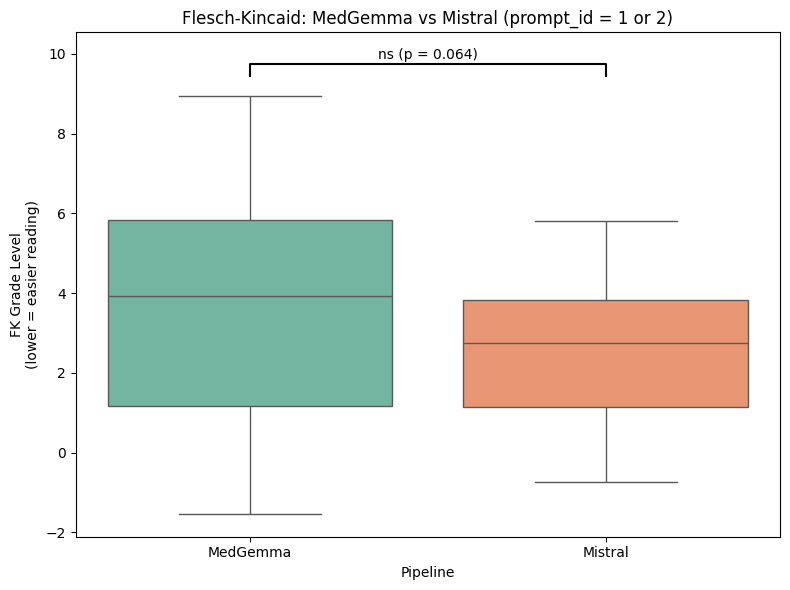

Saved: fk_boxplot_2nd_round_pvalue.png


In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from textstat import textstat
from scipy import stats

base = "/Users/joannehui/Desktop/fyp/2nd round eval"

# MedGemma
med_df = pd.read_csv(f"{base}/Clear_test_finetuned_eval_medgemma.csv", header=1)
med_df.columns = med_df.columns.str.strip()
med_df = med_df.loc[:, ~med_df.columns.str.contains(r"^Unnamed")]
med_df["prompt_id"] = pd.to_numeric(med_df["prompt_id"], errors="coerce")
med_df = med_df[med_df["prompt_id"].isin([1, 2])].copy()
med_texts = med_df["medgemma_pseudolabel"].fillna("").astype(str)
med_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in med_texts]

# Mistral
mis_df = pd.read_csv(f"{base}/CLEAR_test_finetuned_eval_USE.csv", header=1)
mis_df.columns = mis_df.columns.str.strip()
mis_df = mis_df.loc[:, ~mis_df.columns.str.contains(r"^Unnamed")]
mis_df["prompt_id"] = pd.to_numeric(mis_df["prompt_id"], errors="coerce")
mis_df = mis_df[mis_df["prompt_id"].isin([1, 2])].copy()
mis_texts = mis_df["mistral_finetuned_lay_en"].fillna("").astype(str)
mis_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in mis_texts]

fk_long = pd.concat([
    pd.DataFrame({"pipeline": "MedGemma", "fk_grade": med_fk}),
    pd.DataFrame({"pipeline": "Mistral", "fk_grade": mis_fk}),
], ignore_index=True).dropna(subset=["fk_grade"])

# Welch t-test
med_vals = fk_long.loc[fk_long["pipeline"] == "MedGemma", "fk_grade"]
mis_vals = fk_long.loc[fk_long["pipeline"] == "Mistral", "fk_grade"]
t_stat, p_val = stats.ttest_ind(med_vals, mis_vals, equal_var=False)

plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=fk_long, x="pipeline", y="fk_grade", palette="Set2")


plt.title("Flesch-Kincaid: MedGemma vs Mistral (prompt_id = 1 or 2)")
plt.ylabel("FK Grade Level\n(lower = easier reading)")
plt.xlabel("Pipeline")

# significance bar
x1, x2 = 0, 1
y = fk_long["fk_grade"].max() + 0.5
h = 0.3
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")
ax.text((x1 + x2) / 2, y + h + 0.05, f"ns (p = {p_val:.3f})",
        ha="center", va="bottom", color="black")

plt.ylim(top=y + h + 0.8)
plt.tight_layout()
plt.savefig("fk_boxplot_2nd_round_pvalue.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fk_boxplot_2nd_round_pvalue.png")

/var/folders/f0/gmcfk1sx03j_rzh2hrm4mnr80000gp/T/ipykernel_30359/2789930532.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


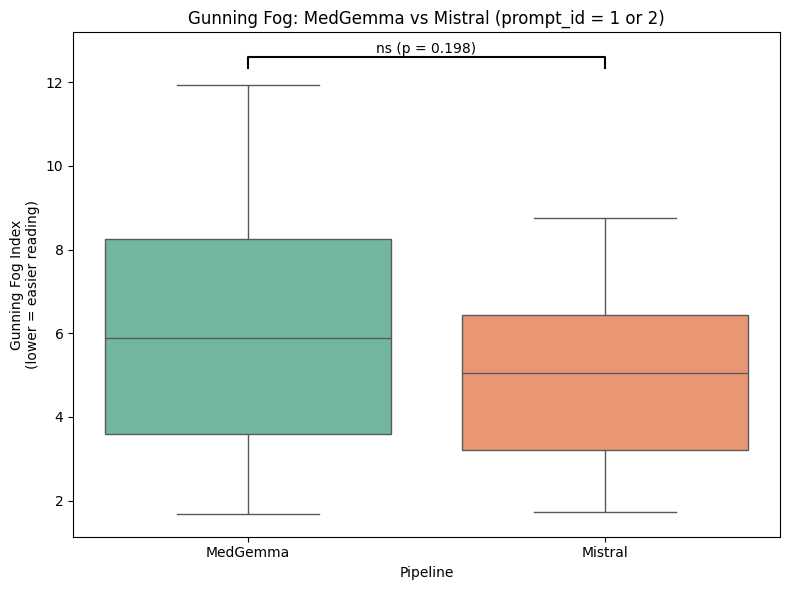

Saved: gf_boxplot_2nd_round_pvalue.png


In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from textstat import textstat
from scipy import stats

base = "/Users/joannehui/Desktop/fyp/2nd round eval"

# MedGemma
med_df = pd.read_csv(f"{base}/Clear_test_finetuned_eval_medgemma.csv", header=1)
med_df.columns = med_df.columns.str.strip()
med_df = med_df.loc[:, ~med_df.columns.str.contains(r"^Unnamed")]
med_df["prompt_id"] = pd.to_numeric(med_df["prompt_id"], errors="coerce")
med_df = med_df[med_df["prompt_id"].isin([1, 2])].copy()

med_texts = med_df["medgemma_pseudolabel"].fillna("").astype(str)
med_gf = [textstat.gunning_fog(t) if t.strip() else np.nan for t in med_texts]

# Mistral
mis_df = pd.read_csv(f"{base}/CLEAR_test_finetuned_eval_USE.csv", header=1)
mis_df.columns = mis_df.columns.str.strip()
mis_df = mis_df.loc[:, ~mis_df.columns.str.contains(r"^Unnamed")]
mis_df["prompt_id"] = pd.to_numeric(mis_df["prompt_id"], errors="coerce")
mis_df = mis_df[mis_df["prompt_id"].isin([1, 2])].copy()

mis_texts = mis_df["mistral_finetuned_lay_en"].fillna("").astype(str)
mis_gf = [textstat.gunning_fog(t) if t.strip() else np.nan for t in mis_texts]

# Long-form dataframe
gf_long = pd.concat([
    pd.DataFrame({"pipeline": "MedGemma", "gunning_fog": med_gf}),
    pd.DataFrame({"pipeline": "Mistral", "gunning_fog": mis_gf}),
], ignore_index=True).dropna(subset=["gunning_fog"])

# Welch t-test
med_vals = gf_long.loc[gf_long["pipeline"] == "MedGemma", "gunning_fog"]
mis_vals = gf_long.loc[gf_long["pipeline"] == "Mistral", "gunning_fog"]
t_stat, p_val = stats.ttest_ind(med_vals, mis_vals, equal_var=False)

# Plot
plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    data=gf_long,
    x="pipeline",
    y="gunning_fog",
    palette="Set2",
    showfliers=False
)

plt.title("Gunning Fog: MedGemma vs Mistral (prompt_id = 1 or 2)")
plt.ylabel("Gunning Fog Index\n(lower = easier reading)")
plt.xlabel("Pipeline")

# significance bar
x1, x2 = 0, 1
y = gf_long["gunning_fog"].max() + 0.4
h = 0.25
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")
ax.text((x1 + x2) / 2, y + h + 0.03, f"ns (p = {p_val:.3f})",
        ha="center", va="bottom", color="black")

plt.ylim(top=y + h + 0.6)
plt.tight_layout()
plt.savefig("gf_boxplot_2nd_round_pvalue.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: gf_boxplot_2nd_round_pvalue.png")

## compare between models

/var/folders/f0/gmcfk1sx03j_rzh2hrm4mnr80000gp/T/ipykernel_30359/357579559.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/f0/gmcfk1sx03j_rzh2hrm4mnr80000gp/T/ipykernel_30359/357579559.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


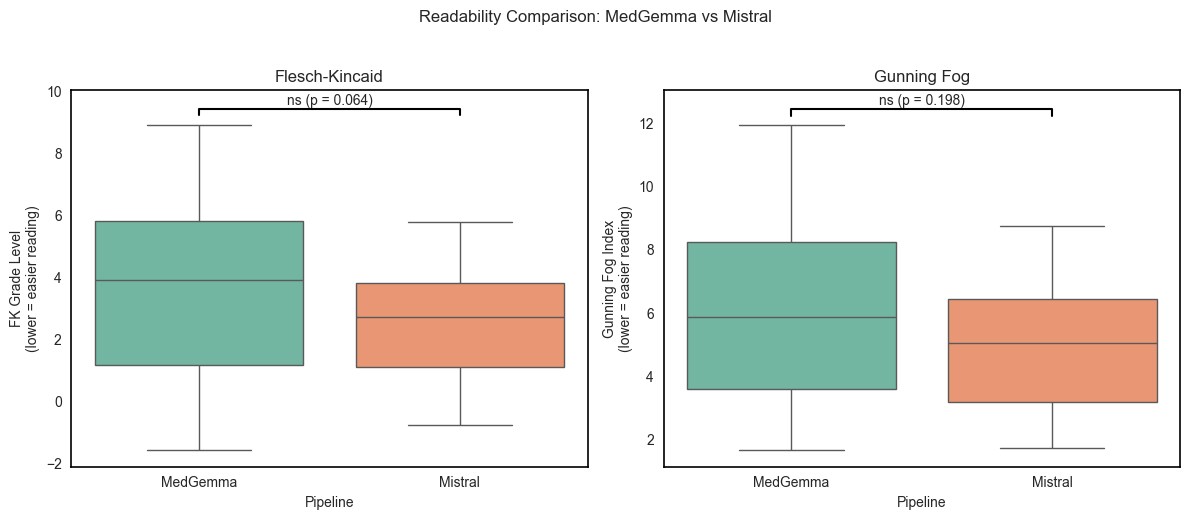

Saved: readability_boxplot_2ndround_2panel.png


In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from textstat import textstat
from scipy import stats

base = "/Users/joannehui/Desktop/fyp/2nd round eval"

# ---------- MedGemma ----------
med_df = pd.read_csv(f"{base}/Clear_test_finetuned_eval_medgemma.csv", header=1)
med_df.columns = med_df.columns.str.strip()
med_df = med_df.loc[:, ~med_df.columns.str.contains(r"^Unnamed")]
med_df["prompt_id"] = pd.to_numeric(med_df["prompt_id"], errors="coerce")
med_df = med_df[med_df["prompt_id"].isin([1, 2])].copy()
med_texts = med_df["medgemma_pseudolabel"].fillna("").astype(str)

# ---------- Mistral ----------
mis_df = pd.read_csv(f"{base}/CLEAR_test_finetuned_eval_USE.csv", header=1)
mis_df.columns = mis_df.columns.str.strip()
mis_df = mis_df.loc[:, ~mis_df.columns.str.contains(r"^Unnamed")]
mis_df["prompt_id"] = pd.to_numeric(mis_df["prompt_id"], errors="coerce")
mis_df = mis_df[mis_df["prompt_id"].isin([1, 2])].copy()
mis_texts = mis_df["mistral_finetuned_lay_en"].fillna("").astype(str)

# ---------- FK ----------
med_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in med_texts]
mis_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in mis_texts]

fk_long = pd.concat([
    pd.DataFrame({"pipeline": "MedGemma", "score": med_fk}),
    pd.DataFrame({"pipeline": "Mistral", "score": mis_fk}),
], ignore_index=True).dropna(subset=["score"])

fk_med_vals = fk_long.loc[fk_long["pipeline"] == "MedGemma", "score"]
fk_mis_vals = fk_long.loc[fk_long["pipeline"] == "Mistral", "score"]
fk_t, fk_p = stats.ttest_ind(fk_med_vals, fk_mis_vals, equal_var=False)

# ---------- GF ----------
med_gf = [textstat.gunning_fog(t) if t.strip() else np.nan for t in med_texts]
mis_gf = [textstat.gunning_fog(t) if t.strip() else np.nan for t in mis_texts]

gf_long = pd.concat([
    pd.DataFrame({"pipeline": "MedGemma", "score": med_gf}),
    pd.DataFrame({"pipeline": "Mistral", "score": mis_gf}),
], ignore_index=True).dropna(subset=["score"])

gf_med_vals = gf_long.loc[gf_long["pipeline"] == "MedGemma", "score"]
gf_mis_vals = gf_long.loc[gf_long["pipeline"] == "Mistral", "score"]
gf_t, gf_p = stats.ttest_ind(gf_med_vals, gf_mis_vals, equal_var=False)

# ---------- Plot ----------
sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# FK box
sns.boxplot(
    data=fk_long,
    x="pipeline",
    y="score",
    palette="Set2",
    showfliers=False,
    ax=axes[0]
)
axes[0].set_title("Flesch-Kincaid")
axes[0].set_ylabel("FK Grade Level\n(lower = easier reading)")
axes[0].set_xlabel("Pipeline")

x1, x2 = 0, 1
y = fk_long["score"].max() + 0.3
h = 0.2
fk_label = f"p = {fk_p:.2e}" if fk_p < 0.001 else f"ns (p = {fk_p:.3f})"
axes[0].plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")
axes[0].text((x1 + x2) / 2, y + h + 0.03, fk_label, ha="center", va="bottom")
axes[0].set_ylim(top=y + h + 0.6)

# GF box
sns.boxplot(
    data=gf_long,
    x="pipeline",
    y="score",
    palette="Set2",
    showfliers=False,
    ax=axes[1]
)
axes[1].set_title("Gunning Fog")
axes[1].set_ylabel("Gunning Fog Index\n(lower = easier reading)")
axes[1].set_xlabel("Pipeline")

y = gf_long["score"].max() + 0.3
h = 0.2
gf_label = f"p = {gf_p:.2e}" if gf_p < 0.001 else f"ns (p = {gf_p:.3f})"
axes[1].plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")
axes[1].text((x1 + x2) / 2, y + h + 0.03, gf_label, ha="center", va="bottom")
axes[1].set_ylim(top=y + h + 0.6)

# panel borders = the "two boxes" look
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor("black")

plt.suptitle("Readability Comparison: MedGemma vs Mistral", y=1.03)
plt.tight_layout()
plt.savefig("readability_boxplot_2ndround_2panel.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: readability_boxplot_2ndround_2panel.png")

# same thing for public data in case i forget to update that on github

/var/folders/f0/gmcfk1sx03j_rzh2hrm4mnr80000gp/T/ipykernel_30359/3589746684.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/f0/gmcfk1sx03j_rzh2hrm4mnr80000gp/T/ipykernel_30359/3589746684.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


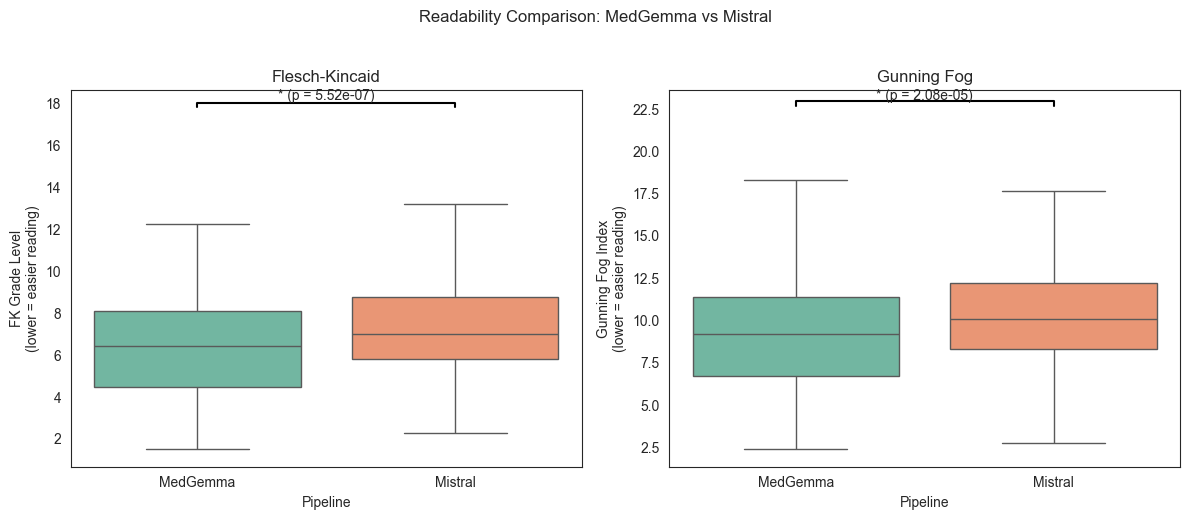

Saved: readability_boxplot_public_2panel.png


In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from textstat import textstat
from scipy import stats

base = "/Users/joannehui/Desktop/fyp/padchest/Reports_public"

# ---------- FK ----------
med_df = pd.read_csv(f"{base}/reports_500_medgemma_lay.csv")
med_texts = med_df["medgemma_lay_en"].fillna("").astype(str)
med_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in med_texts]

mis_df = pd.read_csv(f"{base}/mistral_clean_lay.csv")
mis_texts = mis_df["lay_translation"].fillna("").astype(str)
mis_fk = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in mis_texts]

fk_long = pd.concat([
    pd.DataFrame({"pipeline": "MedGemma", "score": med_fk}),
    pd.DataFrame({"pipeline": "Mistral", "score": mis_fk}),
], ignore_index=True).dropna(subset=["score"])

fk_med_vals = fk_long.loc[fk_long["pipeline"] == "MedGemma", "score"]
fk_mis_vals = fk_long.loc[fk_long["pipeline"] == "Mistral", "score"]
fk_t, fk_p = stats.ttest_ind(fk_med_vals, fk_mis_vals, equal_var=False)

# ---------- GF ----------
med_gf = [textstat.gunning_fog(t) if t.strip() else np.nan for t in med_texts]
mis_gf = [textstat.gunning_fog(t) if t.strip() else np.nan for t in mis_texts]

gf_long = pd.concat([
    pd.DataFrame({"pipeline": "MedGemma", "score": med_gf}),
    pd.DataFrame({"pipeline": "Mistral", "score": mis_gf}),
], ignore_index=True).dropna(subset=["score"])

gf_med_vals = gf_long.loc[gf_long["pipeline"] == "MedGemma", "score"]
gf_mis_vals = gf_long.loc[gf_long["pipeline"] == "Mistral", "score"]
gf_t, gf_p = stats.ttest_ind(gf_med_vals, gf_mis_vals, equal_var=False)

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# FK plot
sns.boxplot(
    data=fk_long,
    x="pipeline",
    y="score",
    palette="Set2",
    showfliers=False,
    ax=axes[0]
)
axes[0].set_title("Flesch-Kincaid")
axes[0].set_ylabel("FK Grade Level\n(lower = easier reading)")
axes[0].set_xlabel("Pipeline")

x1, x2 = 0, 1
y = fk_long["score"].max() + 0.3
h = 0.2
axes[0].plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")
axes[0].text((x1+x2)/2, y+h+0,
             ("ns" if fk_p >= 0.05 else "*") + f" (p = {fk_p:.2e})",
             ha="center", va="bottom")
axes[0].set_ylim(top=y+h+0.6)

# GF plot
sns.boxplot(
    data=gf_long,
    x="pipeline",
    y="score",
    palette="Set2",
    showfliers=False,
    ax=axes[1]
)
axes[1].set_title("Gunning Fog")
axes[1].set_ylabel("Gunning Fog Index\n(lower = easier reading)")
axes[1].set_xlabel("Pipeline")

y = gf_long["score"].max() - 0.1
h = 0.3
axes[1].plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="black")
axes[1].text((x1+x2)/2, y+h-0.15,
             ("ns" if gf_p >= 0.05 else "*") + f" (p = {gf_p:.2e})",
             ha="center", va="bottom")
axes[1].set_ylim(top=y+h+0.6)

plt.suptitle("Readability Comparison: MedGemma vs Mistral", y=1.03)
plt.tight_layout()
plt.savefig("readability_boxplot_public_2panel.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: readability_boxplot_public_2panel.png")

# Stuff for Between prompt comparison

In [1]:
import pandas as pd
import numpy as np
from textstat import textstat

base = "/Users/joannehui/Desktop/fyp/2nd round eval"

configs = [
    ("MedGemma", f"{base}/Clear_test_finetuned_eval_medgemma.csv", "medgemma_pseudolabel"),
    ("Mistral", f"{base}/CLEAR_test_finetuned_eval_USE.csv", "mistral_finetuned_lay_en"),
]

rows = []

for model, path, text_col in configs:
    df = pd.read_csv(path, header=1)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]

    df["prompt_id"] = pd.to_numeric(df["prompt_id"], errors="coerce")
    df = df[df["prompt_id"].isin([1, 2])].copy()

    texts = df[text_col].fillna("").astype(str)

    df["FK"] = [
        textstat.flesch_kincaid_grade(t) if t.strip() else np.nan
        for t in texts
    ]
    df["GF"] = [
        textstat.gunning_fog(t) if t.strip() else np.nan
        for t in texts
    ]

    summary = (
        df.groupby("prompt_id")[["FK", "GF"]]
        .agg(["count", "mean", "std"])
        .round(3)
    )

    for prompt_id in [1, 2]:
        rows.append({
            "model": model,
            "prompt_id": prompt_id,
            "n": summary.loc[prompt_id, ("FK", "count")],
            "mean_FK": summary.loc[prompt_id, ("FK", "mean")],
            "std_FK": summary.loc[prompt_id, ("FK", "std")],
            "mean_GF": summary.loc[prompt_id, ("GF", "mean")],
            "std_GF": summary.loc[prompt_id, ("GF", "std")],
        })

prompt_summary = pd.DataFrame(rows)
prompt_summary

,model,prompt_id,n,mean_FK,std_FK,mean_GF,std_GF
0,MedGemma,1,17,6.201,1.779,8.485,1.797
1,MedGemma,2,17,1.201,1.724,3.350,1.321
2,Mistral,1,17,3.718,1.304,6.394,1.648
3,Mistral,2,17,1.411,1.184,3.806,1.542


In [2]:
prompt_summary = prompt_summary.sort_values(["prompt_id", "model"]).reset_index(drop=True)
prompt_summary

,model,prompt_id,n,mean_FK,std_FK,mean_GF,std_GF
0,MedGemma,1,17,6.201,1.779,8.485,1.797
1,Mistral,1,17,3.718,1.304,6.394,1.648
2,MedGemma,2,17,1.201,1.724,3.350,1.321
3,Mistral,2,17,1.411,1.184,3.806,1.542


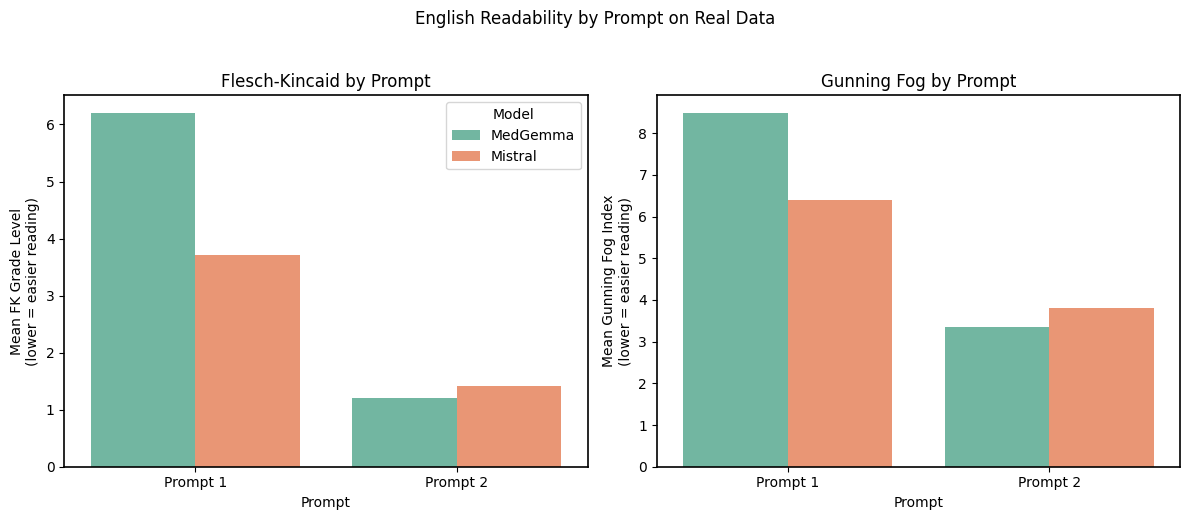

Saved: readability_by_prompt_2panel.png


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = prompt_summary.copy()
plot_df["prompt"] = plot_df["prompt_id"].map({1: "Prompt 1", 2: "Prompt 2"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# FK
sns.barplot(
    data=plot_df,
    x="prompt",
    y="mean_FK",
    hue="model",
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Flesch-Kincaid by Prompt")
axes[0].set_ylabel("Mean FK Grade Level\n(lower = easier reading)")
axes[0].set_xlabel("Prompt")

# GF
sns.barplot(
    data=plot_df,
    x="prompt",
    y="mean_GF",
    hue="model",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Gunning Fog by Prompt")
axes[1].set_ylabel("Mean Gunning Fog Index\n(lower = easier reading)")
axes[1].set_xlabel("Prompt")

# Make borders visible to match your style
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor("black")

# Keep only one legend
axes[0].legend(title="Model")
axes[1].legend_.remove()

plt.suptitle("English Readability by Prompt on Real Data", y=1.03)
plt.tight_layout()
plt.savefig("readability_by_prompt_2panel.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: readability_by_prompt_2panel.png")

In [6]:
import pandas as pd
import numpy as np
from textstat import textstat
from scipy import stats

base = "/Users/joannehui/Desktop/fyp/2nd round eval"

configs = [
    ("MedGemma", f"{base}/Clear_test_finetuned_eval_medgemma.csv", "medgemma_pseudolabel"),
    ("Mistral", f"{base}/CLEAR_test_finetuned_eval_USE.csv", "mistral_finetuned_lay_en"),
]

all_rows = []

for model, path, text_col in configs:
    df = pd.read_csv(path, header=1)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]

    df["prompt_id"] = pd.to_numeric(df["prompt_id"], errors="coerce")
    df = df[df["prompt_id"].isin([1, 2])].copy()

    texts = df[text_col].fillna("").astype(str)

    df["FK"] = [textstat.flesch_kincaid_grade(t) if t.strip() else np.nan for t in texts]
    df["GF"] = [textstat.gunning_fog(t) if t.strip() else np.nan for t in texts]

    df["model"] = model
    all_rows.append(df[["model", "prompt_id", "FK", "GF"]])

scores = pd.concat(all_rows, ignore_index=True).dropna()

def cohens_d(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    pooled_sd = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_sd

def mean_diff_ci_welch(x, y, alpha=0.05):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    nx, ny = len(x), len(y)

    diff = mx - my
    se = np.sqrt(vx/nx + vy/ny)

    df = (vx/nx + vy/ny)**2 / ((vx**2)/((nx**2)*(nx-1)) + (vy**2)/((ny**2)*(ny-1)))
    t_crit = stats.t.ppf(1 - alpha/2, df)

    lower = diff - t_crit * se
    upper = diff + t_crit * se
    return diff, lower, upper

results = []

comparisons = [
    ("Prompt 1: MedGemma vs Mistral",
     scores[(scores.model=="MedGemma") & (scores.prompt_id==1)],
     scores[(scores.model=="Mistral") & (scores.prompt_id==1)]),

    ("Prompt 2: MedGemma vs Mistral",
     scores[(scores.model=="MedGemma") & (scores.prompt_id==2)],
     scores[(scores.model=="Mistral") & (scores.prompt_id==2)]),

    ("MedGemma: Prompt 1 vs Prompt 2",
     scores[(scores.model=="MedGemma") & (scores.prompt_id==1)],
     scores[(scores.model=="MedGemma") & (scores.prompt_id==2)]),

    ("Mistral: Prompt 1 vs Prompt 2",
     scores[(scores.model=="Mistral") & (scores.prompt_id==1)],
     scores[(scores.model=="Mistral") & (scores.prompt_id==2)]),
]

for label, g1, g2 in comparisons:
    for metric in ["FK", "GF"]:
        x = g1[metric].dropna()
        y = g2[metric].dropna()

        t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)
        d = cohens_d(x, y)
        diff, ci_low, ci_high = mean_diff_ci_welch(x, y)

        results.append({
            "comparison": label,
            "metric": metric,
            "group1_n": len(x),
            "group2_n": len(y),
            "group1_mean": round(x.mean(), 3),
            "group2_mean": round(y.mean(), 3),
            "mean_diff": round(diff, 3),
            "ci_low_95": round(ci_low, 3),
            "ci_high_95": round(ci_high, 3),
            "t_stat": round(t_stat, 3),
            "p_value": p_val,
            "cohens_d": round(d, 3),
            "significant_0.05": "Yes" if p_val < 0.05 else "No"
        })

stats_table = pd.DataFrame(results)
stats_table

,comparison,metric,group1_n,group2_n,group1_mean,group2_mean,mean_diff,ci_low_95,ci_high_95,t_stat,p_value,cohens_d,significant_0.05
0,Prompt 1: MedGemma vs Mistral,FK,17,17,6.201,3.718,2.484,1.390,3.577,4.642,6.680179e-05,1.592,Yes
1,Prompt 1: MedGemma vs Mistral,GF,17,17,8.485,6.394,2.090,0.885,3.295,3.535,1.275784e-03,1.212,Yes
2,Prompt 2: MedGemma vs Mistral,FK,17,17,1.201,1.411,-0.210,-1.249,0.828,-0.415,6.815662e-01,-0.142,No
3,Prompt 2: MedGemma vs Mistral,GF,17,17,3.350,3.806,-0.456,-1.460,0.548,-0.927,3.610386e-01,-0.318,No
4,MedGemma: Prompt 1 vs Prompt 2,FK,17,17,6.201,1.201,5.000,3.776,6.224,8.324,1.659407e-09,2.855,Yes
5,MedGemma: Prompt 1 vs Prompt 2,GF,17,17,8.485,3.350,5.135,4.029,6.241,9.493,1.859003e-10,3.256,Yes
6,Mistral: Prompt 1 vs Prompt 2,FK,17,17,3.718,1.411,2.306,1.436,3.177,5.397,6.434295e-06,1.851,Yes
7,Mistral: Prompt 1 vs Prompt 2,GF,17,17,6.394,3.806,2.588,1.473,3.703,4.728,4.415165e-05,1.622,Yes
